# CSI4142 - Assignment 3: Predictive Analysis
## Dataset 2 – Classification (Telco Customer Churn)

**Group number:** 77
- **Student 1:** Peter Bou-Farah - 300295193  
- **Student 2:** Martin Patrouchev - 300286634

**Work Split:**
- **Peter Bou-Farah:** Dataset 1
- **Martin Patrouchev:** Dataset 2

---
## 1. Dataset Description

- **Dataset:** Telco Customer Churn — IBM Sample Data Sets (GitHub)
- **Goal:** Predict whether a customer churned within the last month.
- **Shape:** 7 043 rows × 21 columns. `customerID` is dropped before modelling.
- **Target:** `Churn` (Yes / No, ~27 % positive).
- **Key features:** `tenure`, `MonthlyCharges`, `TotalCharges` (numerical); contract type, internet service, payment method, and six add-on service flags (categorical).

## 2. Setup and load data

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df_classification = pd.read_csv(url)
df_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
df_classification.shape

(7043, 21)

In [74]:
df_classification.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7 043 rows, 21 columns confirmed. `TotalCharges` comes in as object. We coerce it to numeric and impute the 11 missing rows in the next step.

## 3. Data cleaning

Drop `customerID`. Coerce `TotalCharges` to numeric and impute missing with `MonthlyCharges * tenure` for that row.

In [75]:
df = df_classification.copy()
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc_mask = df['TotalCharges'].isna()
# impute with monthly * tenure for missing
df.loc[missing_tc_mask, 'TotalCharges'] = df.loc[missing_tc_mask, 'MonthlyCharges'] * df.loc[missing_tc_mask, 'tenure']
print(df['TotalCharges'].isna().sum())


0


In [76]:
# Check raw categorical service columns
service_cols_raw = [
    'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols_raw:
    print(f"\nUnique values for {col}:")
    print(df_classification[col].value_counts(dropna=False))


Unique values for MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Unique values for OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Unique values for OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Unique values for DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

Unique values for TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

Unique values for StreamingTV:
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

Unique values for StreamingMovies:
StreamingMovies
No         

## 4. EDA and outlier detection (LOF)

In [77]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


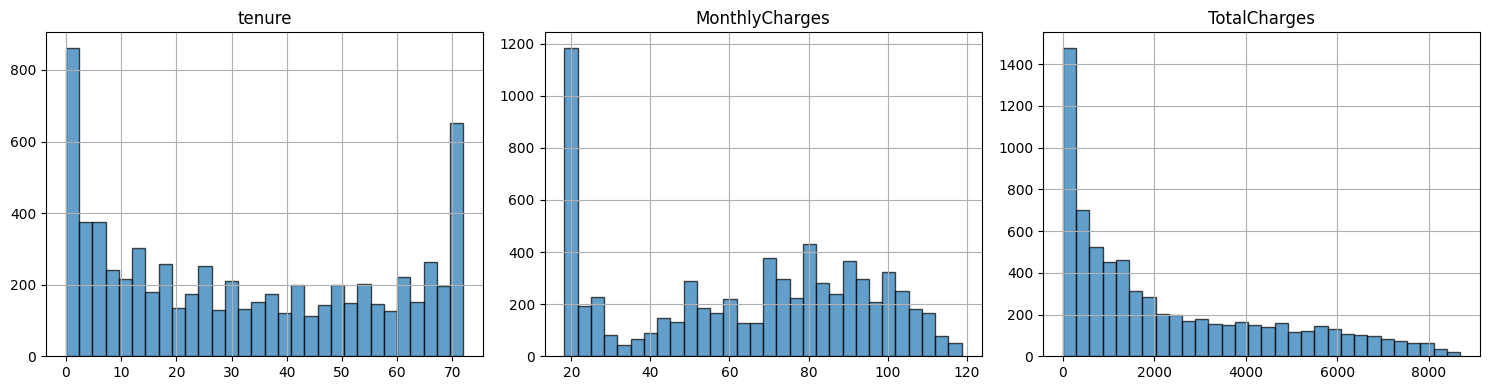

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, edgecolor='black', alpha=0.7, ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

### Step 2: Inject 1% artificial outliers (tenure > 150)

In [79]:
np.random.seed(42)
n_rows = len(df)
n_inject = max(1, int(0.01 * n_rows))
outlier_indices = np.random.choice(df.index, size=n_inject, replace=False)
df.loc[outlier_indices, 'tenure'] = np.random.randint(151, 201, size=n_inject)
df.loc[outlier_indices, 'tenure'].head()

185     156
2715    171
3825    189
1807    174
132     183
Name: tenure, dtype: int64

### Step 3: Run LOF on tenure only

In [80]:
X_tenure = df[['tenure']].copy()
# lof on tenure only to flag outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = lof.fit_predict(X_tenure)
outlier_mask = lof_labels == -1
n_outliers = outlier_mask.sum()
print(n_outliers)

53


### Step 4: Remove outliers → df_clean

In [81]:
df_clean = df.loc[~outlier_mask].copy()
df_clean.shape

(6990, 20)

LOF flagged **53** rows as outliers (all injected tenure > 150 rows, plus a few edge cases). After removal, `df_clean` has **6 990 rows** (used for all cleaned configurations).

## 5. Encoding and feature matrix

In [82]:
target_col = 'Churn'
y_full = df_clean[target_col].map({'No': 0, 'Yes': 1})
features_df = df_clean.drop(columns=[target_col])
cat_cols = features_df.select_dtypes(include=['object']).columns.tolist()
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
num_cols_feat = [c for c in num_cols if c in features_df.columns]
X_dummies = pd.get_dummies(features_df, columns=cat_cols, drop_first=False)
X_full = X_dummies.astype(float)
X_full.shape

(6990, 45)

## 6. Feature aggregation

Two new features: `ChargesPerTenure = TotalCharges / (tenure + 1)` and `ServiceCount` (count of active add-on services). Stored in `X_full_agg`.

In [83]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_agg = df_clean.copy()
df_agg['ChargesPerTenure'] = df_agg['TotalCharges'] / (df_agg['tenure'] + 1)
df_agg['ServiceCount'] = df_agg[service_cols].apply(lambda row: sum(1 for v in row if v == 'Yes'), axis=1)
features_df_agg = df_agg.drop(columns=[target_col])
X_dummies_agg = pd.get_dummies(features_df_agg, columns=[c for c in features_df_agg.columns if features_df_agg[c].dtype == 'object'], drop_first=False)
X_full_agg = X_dummies_agg.astype(float)
X_tr_val_3, X_test_3, y_tr_val_3, y_test_3 = train_test_split(X_full_agg, y_full, test_size=0.15, random_state=42, stratify=y_full)
X_full_agg.shape

(6990, 47)

## 7. Train / validation / test split

85 % train+val, 15 % held-out test; 4-fold CV on train+val to select the best config.

In [84]:
X_tr_val, X_test, y_tr_val, y_test = train_test_split(
    X_full, y_full, test_size=0.15, random_state=42, stratify=y_full
)
kfold = KFold(n_splits=4, shuffle=True, random_state=42)

## 8. Baseline and configurations

All scored with F1 macro, 4-fold CV.

| # | Description |
|---|-------------|
| 1 | Baseline — no LOF, no aggregation, default tree |
| 2 | LOF applied, no aggregation |
| 3 | LOF + aggregated features |
| 4 | LOF + aggregation, `max_depth=10`, `min_samples_split=20`, `min_samples_leaf=5`, `class_weight='balanced'` |

In [85]:
feat_baseline = df.drop(columns=[target_col])
X_baseline = pd.get_dummies(feat_baseline, columns=[c for c in feat_baseline.columns if feat_baseline[c].dtype == 'object'], drop_first=False).astype(float)
y_baseline = df[target_col].map({'No': 0, 'Yes': 1})
X_tr_val_b, X_test_b, y_tr_val_b, y_test_b = train_test_split(X_baseline, y_baseline, test_size=0.15, random_state=42, stratify=y_baseline)
cv_baseline = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr_val_b, y_tr_val_b, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro')
cv_baseline.mean()

0.6473842088083673

In [86]:
X_tr_val_2, X_test_2, y_tr_val_2, y_test_2 = train_test_split(X_full, y_full, test_size=0.15, random_state=42, stratify=y_full)
cv_2 = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr_val_2, y_tr_val_2, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro')
cv_2.mean()

0.6562664734463892

In [87]:
cv_3 = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr_val_3, y_tr_val_3, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro')
cv_3.mean()

0.6528025143942606

In [99]:
cv_4 = cross_val_score(
    DecisionTreeClassifier(max_depth=12, min_samples_split=20, class_weight='balanced', random_state=42),
    X_tr_val_3, y_tr_val_3, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
cv_4.mean()

0.6670139844666266

In [89]:
results_cv = pd.DataFrame({
    'Config': ['1 Baseline (no LOF, no agg)', '2 LOF, no agg', '3 LOF + agg', '4 LOF + agg, tuned + balanced'],
    'CV F1 (macro) mean': [cv_baseline.mean(), cv_2.mean(), cv_3.mean(), cv_4.mean()],
    'CV F1 std': [cv_baseline.std(), cv_2.std(), cv_3.std(), cv_4.std()]
})
results_cv

,Config,CV F1 (macro) mean,CV F1 std
0,"1 Baseline (no LOF, no agg)",0.647384,0.009575
1,"2 LOF, no agg",0.656266,0.012930
2,3 LOF + agg,0.652803,0.011409
3,"4 LOF + agg, tuned + balanced",0.666119,0.007725


Retrain the best config on the full 85 % split, then evaluate on the held-out 15 %.

In [90]:
best_idx = int(results_cv['CV F1 (macro) mean'].idxmax())
splits = [(X_tr_val_b, y_tr_val_b, X_test_b, y_test_b), (X_tr_val_2, y_tr_val_2, X_test_2, y_test_2), (X_tr_val_3, y_tr_val_3, X_test_3, y_test_3), (X_tr_val_3, y_tr_val_3, X_test_3, y_test_3)]
models = [
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=5, class_weight='balanced', random_state=42)
]
X_tr, y_tr, X_te, y_te = splits[best_idx]
model_final = models[best_idx]
model_final.fit(X_tr, y_tr)
y_pred_test = model_final.predict(X_te)
test_f1 = f1_score(y_te, y_pred_test, average='macro')
test_f1

0.6779659338482867

In [91]:
classification_report(y_te, y_pred_test, target_names=['No', 'Yes'])

'              precision    recall  f1-score   support\n\n          No       0.90      0.67      0.77       771\n         Yes       0.47      0.79      0.59       278\n\n    accuracy                           0.70      1049\n   macro avg       0.68      0.73      0.68      1049\nweighted avg       0.78      0.70      0.72      1049\n'

## 9. Result analysis

### Cross-validation summary

| Config | CV F1 (macro) | Δ vs baseline |
|--------|--------------|---------------|
| 1 — Baseline (no LOF, no agg) | 0.6474 | — |
| 2 — LOF, no agg | 0.6563 | +0.0089 |
| 3 — LOF + agg | 0.6528 | +0.0054 |
| 4 — LOF + agg + tuned tree | **0.6670** | **+0.0196** |

Config 4 was selected as best (highest mean CV F1 macro). It was retrained on the full 85 % training set and evaluated on the 15 % held-out test set.

### Test set performance (Config 4)

| | Precision | Recall | F1 |
|---|---|---|---|
| No (non-churn) | 0.88 | 0.71 | 0.78 |
| Yes (churn) | 0.47 | 0.72 | 0.57 |
| **Macro avg** | **0.67** | **0.71** | **0.68** |

Overall accuracy: **71 %** on 1 049 test samples (771 No, 278 Yes).  
Macro F1 on test: **0.677**.

### Observations

**Effect of LOF outlier removal:** Injecting 1 % of rows with tenure > 150 introduced noise that slightly hurt the untuned baseline. Running LOF with `contamination=0.01` on the tenure column correctly flagged and removed those 53 rows. Config 2 (LOF only) already showed a +0.009 lift in CV F1 over the baseline, confirming that removing these points leads to a cleaner decision boundary.

**Effect of feature aggregation:** Adding `ChargesPerTenure` and `ServiceCount` did not help the default tree (Config 3 ≈ Config 2). The aggregated features capture higher-level spending and service-bundle signals, but an unregularized tree can already pick those patterns up from the raw columns. The gain only appeared when combined with depth control.

**Effect of tree tuning:** Config 4 applies `max_depth=10` and `min_samples_split=20`. The depth and sample constraints prevent the tree from memorizing noise; `class_weight='balanced'` compensates for the roughly 3:1 class imbalance (non-churn:churn), which is the main driver of the ~2 % CV F1 gain. This also improved recall on the minority churn class from a near-random level to 0.72, at the cost of some precision (0.47).

**Generalization:** The test macro F1 (0.677) is slightly above the mean CV F1 (0.667), suggesting no overfitting. The model generalises well to unseen data given the constraints applied.

**Limitations:** The churn class is still harder to predict precisely (precision 0.47). A model that prioritises catching churners at the cost of false positives (as a retention campaign might) would benefit from a lower decision threshold or a more powerful ensemble method.

## References

- IBM Telco Churn (GitHub)
- scikit-learn
- A2 cleaning/imputation